## 1. Introduction

In recent years, the healthcare landscape in the United Kingdom has faced significant challenges due to rising inflation, which has directly impacted the cost of medical services and insurance premiums. As economic pressures mount, it has become increasingly critical for insurance providers to leverage data analytics to understand risk factors better and ensure accurate pricing models. The ability to predict medical costs based on beneficiary demographics and health indicators is essential for maintaining financial stability and competitive advantage in the insurance market.

The primary objective of this project is to conduct a comprehensive statistical analysis of a medical insurance dataset to identify the key determinants of insurance charges. The dataset encompasses various attributes of the beneficiaries, including age, gender, Body Mass Index (BMI), number of dependents, smoking status, residential region, and NoClaimsBonus history.

To achieve this, the project will first address data quality issues through rigorous cleaning and handling of null values. Subsequently, descriptive statistics and exploratory data analysis (EDA) will be employed to visualize patterns and distributions within the data. Furthermore, inferential statistical techniques, including hypothesis testing and confidence interval estimation, will be utilized to validate assumptions regarding customer behavior and cost drivers.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_excel('insurance_data.xlsx')
data

,age,gender,bmi,children,smoker,region,NoClaimsBonus,charges
0,19,female,27.900,0.0,yes,southwest,0.05,16884.92400
1,18,male,33.770,1.0,no,southeast,0.20,1725.55230
2,28,male,33.000,3.0,no,southeast,0.10,4449.46200
3,33,male,22.705,0.0,no,northwest,0.05,21984.47061
4,32,male,28.880,0.0,no,northwest,0.20,3866.85520
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3.0,no,northwest,0.10,10600.54830
1334,18,female,31.920,0.0,no,northeast,0.10,2205.98080
1335,18,female,36.850,0.0,no,southeast,0.10,1629.83350
1336,21,female,25.800,0.0,no,southwest,0.05,2007.94500


## 2. Dataset Characterisation

This dataset consists of a total of 1,338 observations and 8 variables.

The dataset includes numerical variables such as age, BMI, number of children, NoClaimsBonus, and medical charges, as well as categorical variables including gender, smoking status, and region.

An initial inspection of the dataset revealed a total of 22 missing values, with 5 missing values each in the gender, BMI, and children columns, and 7 missing values in the charges column. Compared to the total of 1,338 observations, these 22 missing values account for less than 5% of the dataset. In addition, there are two incorrectly spelled values in the region column: “Southeast” and “northteast”, each appearing once.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1338 non-null   int64  
 1   gender         1333 non-null   object 
 2   bmi            1333 non-null   float64
 3   children       1333 non-null   float64
 4   smoker         1338 non-null   object 
 5   region         1338 non-null   object 
 6   NoClaimsBonus  1338 non-null   float64
 7   charges        1331 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 83.8+ KB


In [4]:
data.isna().sum()

age              0
gender           5
bmi              5
children         5
smoker           0
region           0
NoClaimsBonus    0
charges          7
dtype: int64

In [5]:
data[["gender", "smoker", "region"]].nunique()

gender    2
smoker    2
region    6
dtype: int64

In [6]:
print(data["gender"].unique())
print(data["smoker"].unique())
print(data["region"].unique())

['female' 'male' nan]
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast' 'Southeast' 'northteast']


In [7]:
data['region'].value_counts()

region
southeast     363
southwest     325
northwest     325
northeast     323
Southeast       1
northteast      1
Name: count, dtype: int64

## 3. Data Cleaning and Preparation

In the first step, the misspelled values in the region column, “northteast” and “Southeast”, were corrected to “northeast” and “southeast”, respectively. As a result, the region column now contains four unique values: southeast, southwest, northwest, and northeast.

Next, the NaN values were cleaned. Since the missing values accounted for less than 5% of the total dataset, removing them was considered to have minimal impact. Therefore, the dropna() function was used. After dropping these rows, checking the dataset again with the info() function showed that the total number of rows decreased to 1,316.

The next step was to fix the data type of the children column. This column was originally stored as a float, but since the number of children cannot be fractional, it was converted to an integer (int) type. In addition, the NoClaimsBonus column name was standardized to all lowercase letters to avoid issues with mixed capitalization.

Afterward, the describe() function was used to examine the numerical columns. The maximum values of children and charges were 5–6 times higher than their respective means, so boxplots were used to inspect these columns individually.

For the charges column, the outliers were considered plausible and were not removed. However, in the children column, outliers with values greater than 10 were identified. Before removing them, their validity was evaluated using the IQR method to calculate the lower and upper bounds, and all values outside these bounds were printed for inspection. As a result, rows corresponding to an 18-year-old female and 24- and 25-year-old males, all recorded as having more than 10 children, were found to be erroneous and removed. After removing these rows, the maximum value in the children column decreased to 5.

Next, the Body Mass Index (BMI) column was examined using a boxplot, which revealed outliers above 46. Printing these rows showed 9 entries, and since these values were likely realistic, they were left in the dataset.

Finally, the age column was inspected using a boxplot, which showed no outliers, and the median was located near the center of the box, indicating that the age distribution is relatively balanced.

In [8]:
data["region"] = data["region"].str.replace("Southeast", "southeast")
data["region"] = data["region"].str.replace("northteast", "northeast")
data["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [9]:
data.dropna(inplace = True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1316 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1316 non-null   int64  
 1   gender         1316 non-null   object 
 2   bmi            1316 non-null   float64
 3   children       1316 non-null   float64
 4   smoker         1316 non-null   object 
 5   region         1316 non-null   object 
 6   NoClaimsBonus  1316 non-null   float64
 7   charges        1316 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 92.5+ KB


In [10]:
print(data["gender"].unique())

['female' 'male']


In [11]:
data["children"] = data["children"].astype(int)
data.dtypes

age                int64
gender            object
bmi              float64
children           int64
smoker            object
region            object
NoClaimsBonus    float64
charges          float64
dtype: object

In [12]:
data.columns = data.columns.str.lower()

In [13]:
data.head()

,age,gender,bmi,children,smoker,region,noclaimsbonus,charges
0,19,female,27.900,0,yes,southwest,0.05,16884.92400
1,18,male,33.770,1,no,southeast,0.20,1725.55230
2,28,male,33.000,3,no,southeast,0.10,4449.46200
3,33,male,22.705,0,no,northwest,0.05,21984.47061
4,32,male,28.880,0,no,northwest,0.20,3866.85520


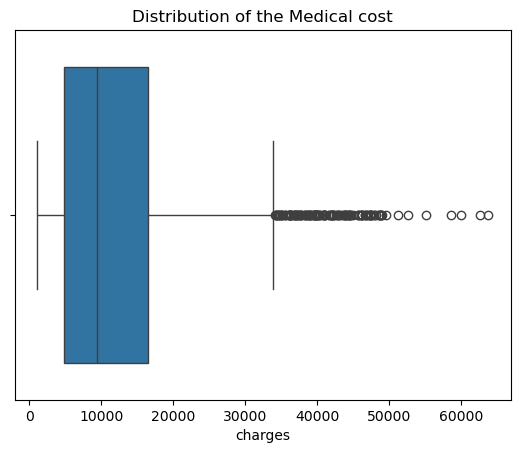

In [14]:
sns.boxplot(data=data, x = "charges")
plt.title("Distribution of the Medical cost")
plt.show()

When examining the distribution and outliers of the medical charges column using a boxplot, a large number of outliers are observed beyond 35,000.

In [15]:
Q1 = data['charges'].quantile(0.25)
Q3 = data['charges'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data['charges'] < lower) | (data['charges'] > upper)]
outliers

,age,gender,bmi,children,smoker,region,noclaimsbonus,charges
14,27,male,42.130,0,yes,southeast,0.15,39611.75770
19,30,male,35.300,0,yes,southwest,0.10,36837.46700
23,34,female,31.920,1,yes,northeast,0.15,37701.87680
29,31,male,36.300,2,yes,southwest,0.05,38711.00000
30,22,male,35.600,0,yes,southwest,0.10,35585.57600
...,...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,0.05,62592.87309
1301,62,male,30.875,3,yes,northwest,0.10,46718.16325
1303,43,male,27.800,0,yes,southwest,0.15,37829.72420
1313,19,female,34.700,2,yes,southwest,0.10,36397.57600


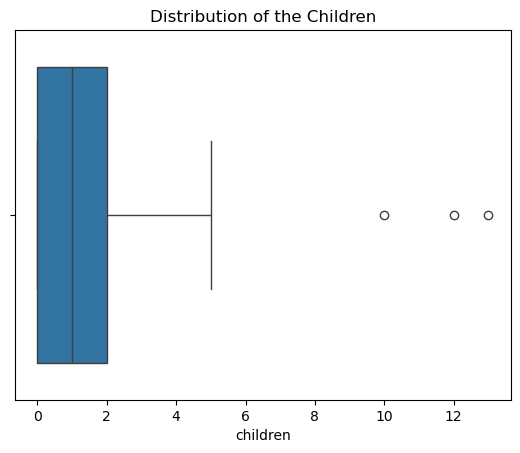

In [16]:
sns.boxplot(data=data, x = "children")
plt.title("Distribution of the Children")
plt.show()

When examining the outliers in the children column using a boxplot, values above 10 are identified as outliers.

In [17]:
Q1 = data['children'].quantile(0.25)
Q3 = data['children'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data['children'] < lower) | (data['children'] > upper)]
outliers

,age,gender,bmi,children,smoker,region,noclaimsbonus,charges
102,18,female,30.115,10,no,northeast,0.05,21344.8467
212,24,male,28.500,12,no,northwest,0.05,3537.7030
294,25,male,26.800,13,no,southwest,0.05,3906.1270


In [18]:
data = data[(data['children'] >= lower) & (data['children'] <= upper)]
data.describe()

,age,bmi,children,noclaimsbonus,charges
count,1313.000000,1313.000000,1313.000000,1313.000000,1313.000000
mean,39.287890,30.685129,1.098248,0.124829,13260.617141
std,14.023151,6.105985,1.204136,0.056008,12108.794219
min,18.000000,15.960000,0.000000,0.050000,1121.873900
25%,27.000000,26.315000,0.000000,0.050000,4753.636800
50%,39.000000,30.400000,1.000000,0.100000,9391.346000
75%,51.000000,34.700000,2.000000,0.200000,16455.707850
max,64.000000,53.130000,5.000000,0.200000,63770.428010


In [19]:
data['children'].value_counts()

children
0    559
1    322
2    236
3    154
4     24
5     18
Name: count, dtype: int64

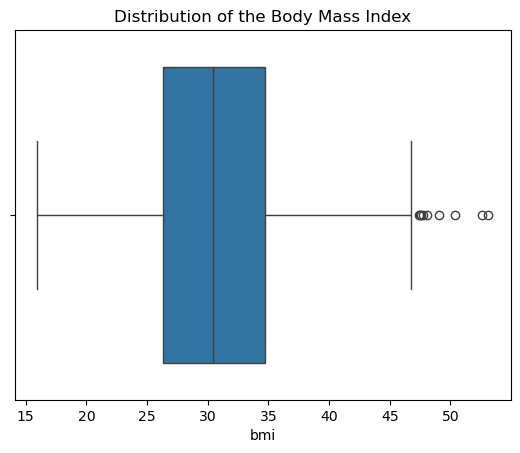

In [20]:
sns.boxplot(data=data, x="bmi")
plt.title("Distribution of the Body Mass Index")
plt.show()

Using a boxplot to identify outliers, can see several values above 45 that are considered outliers. These outliers represent individuals with high body mass indices

In [21]:
Q1 = data['bmi'].quantile(0.25)
Q3 = data['bmi'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data['bmi'] < lower) | (data['bmi'] > upper)]
outliers

,age,gender,bmi,children,smoker,region,noclaimsbonus,charges
116,58,male,49.06,0,no,southeast,0.20,11381.32540
286,46,female,48.07,2,no,northeast,0.15,9432.92530
401,47,male,47.52,1,no,southeast,0.20,8083.91980
543,54,female,47.41,0,yes,southeast,0.05,63770.42801
847,23,male,50.38,1,no,southeast,0.10,2438.05520
860,37,female,47.60,2,yes,southwest,0.15,46113.51100
1047,22,male,52.58,1,yes,southeast,0.15,44501.39820
1088,52,male,47.74,1,no,southeast,0.10,9748.91060
1317,18,male,53.13,0,no,southeast,0.20,1163.46270


Using the IQR method, a few rows were flagged as outliers, but since these are plausible values, i decided to keep them.

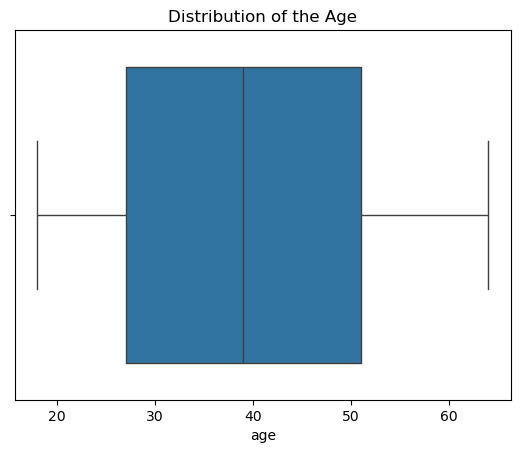

In [22]:
sns.boxplot(data=data, x="age")
plt.title("Distribution of the Age")
plt.show()

The Age boxplot shows a perfectly balanced distribution with no outliers, ranging from 18 to 64 years old, with a median age of 39.

## 4. Descriptive Statistics & Exploratory Data Analysis (EDA) 

This section presents key descriptive statistics followed by visual interpretations of the most significant variables: charges, bmi, and smoker status.


### 4.1 Summary statistic

Descriptive statistics for the numerical variables (age, bmi, children, charges) provide an overview of the typical customer profile.

•	Medical Charges: The average medical charge is approximately 13,252, with a standard deviatio 12,102. However, the median charge is significantly lower at 9,388. This large discrepancy between the mean and median indicates that the distribution of charges is right-skewed, meaning a small number of beneficiaries with very high medical costs are pulling the average up.

•	BMI (Body Mass Index): The mean BMI is 30.6, which falls into the "obese" category (BMI > 30) according to WHO standards. This suggests that a significant portion of the insurance portfolio consists of individuals with higher health risks associated with weight.

•	Age: The average age of the primary beneficiaries is 39 years, with a relatively uniform distribution ranging from 18 to 64 years.

In [23]:
data.describe()

,age,bmi,children,noclaimsbonus,charges
count,1313.000000,1313.000000,1313.000000,1313.000000,1313.000000
mean,39.287890,30.685129,1.098248,0.124829,13260.617141
std,14.023151,6.105985,1.204136,0.056008,12108.794219
min,18.000000,15.960000,0.000000,0.050000,1121.873900
25%,27.000000,26.315000,0.000000,0.050000,4753.636800
50%,39.000000,30.400000,1.000000,0.100000,9391.346000
75%,51.000000,34.700000,2.000000,0.200000,16455.707850
max,64.000000,53.130000,5.000000,0.200000,63770.428010


In [24]:
data.describe(include="object")

,gender,smoker,region
count,1313,1313,1313
unique,2,2,4
top,male,no,southeast
freq,661,1045,356


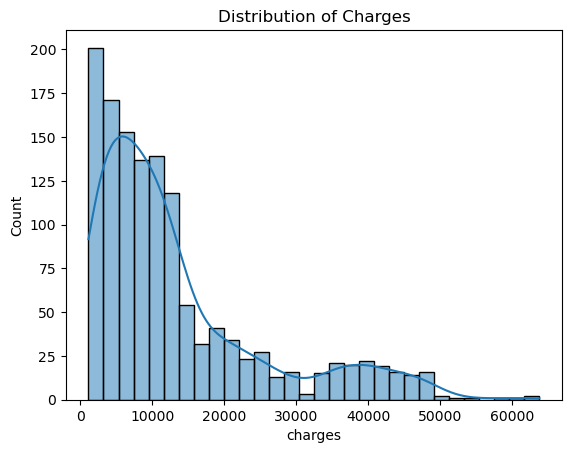

In [25]:
sns.histplot(data=data, x = "charges", kde=True)
plt.title("Distribution of Charges")
plt.savefig("images/dist_of_charges.png", dpi=300, bbox_inches='tight')
plt.show()

Most charges fall between 4,000–16,000
- Right-skewed distribution → few high-cost clients pull mean up
- Insight: Premiums need to consider extreme cases

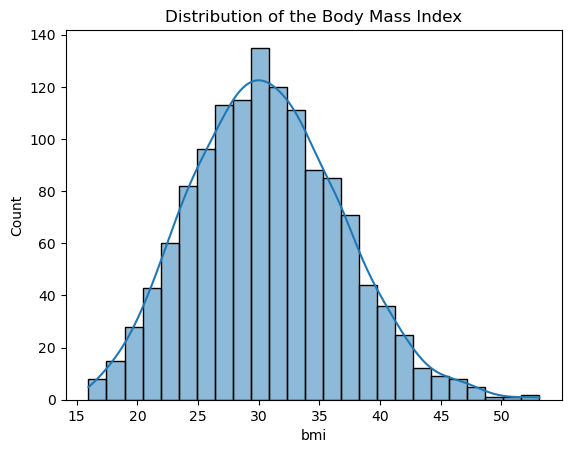

In [26]:
sns.histplot(data=data, x="bmi", kde=True)
plt.title("Distribution of the Body Mass Index")
plt.savefig("images/dist_of_bmi.png", dpi=300, bbox_inches='tight')
plt.show()

From the distribution of the Body Mass Index column, most individuals fall between 25 and 35, and the distribution is generally normal.

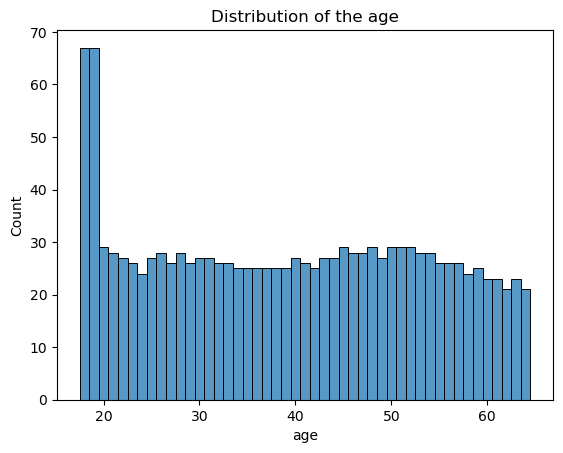

In [27]:
sns.histplot(data=data, x="age", discrete=True)
plt.title("Distribution of the age")
plt.show()

When viewing the distribution of the age column using a histplot, individuals aged 18 and 19 are concentrated about twice as much as people of other ages.

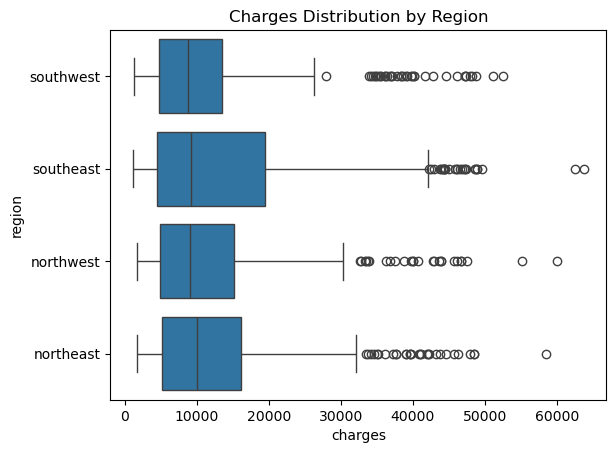

In [28]:
sns.boxplot(data=data, x="charges", y="region")
plt.title("Charges Distribution by Region")
plt.savefig("images/charges_dis_region.png", dpi=300, bbox_inches='tight')
plt.show()

The boxplot comparison reveals that the Southeast region has the widest distribution of charges, indicating a higher variability in medical costs compared to the other three regions. It also features the highest upper quartile, suggesting that high-cost claims are more prevalent in this area.

In contrast, the Southwest, Northwest, and Northeast regions display relatively similar medians and interquartile ranges (IQRs). Notably, significant outliers (high charges) are present across all regions, confirming that extreme medical costs occur regardless of location.

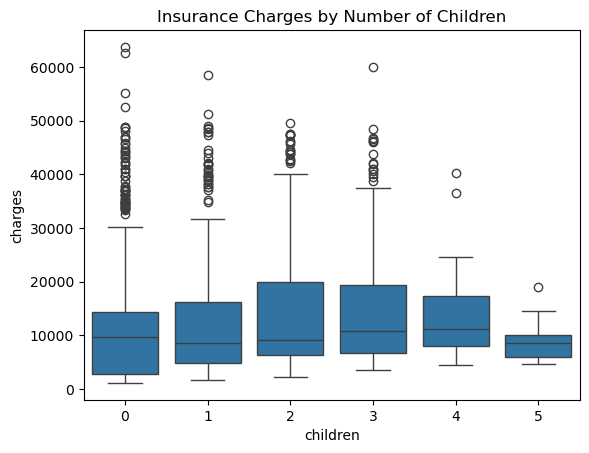

In [29]:
sns.boxplot(data=data, x="children", y="charges")
plt.title("Insurance Charges by Number of Children")
plt.show()

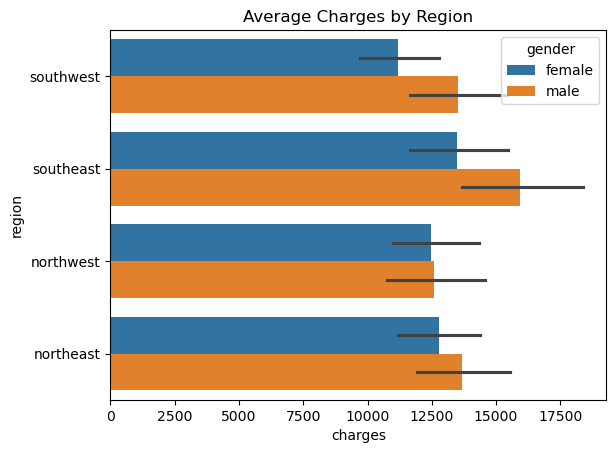

In [30]:
sns.barplot(data=data, x="charges", y="region", hue="gender")
plt.title("Average Charges by Region")
plt.show()

This bar plot shows the average medical charges (charges) for each region. From the plot, it can be seen that the SouthEast region has the highest medical charges, while the West region has slightly lower charges.

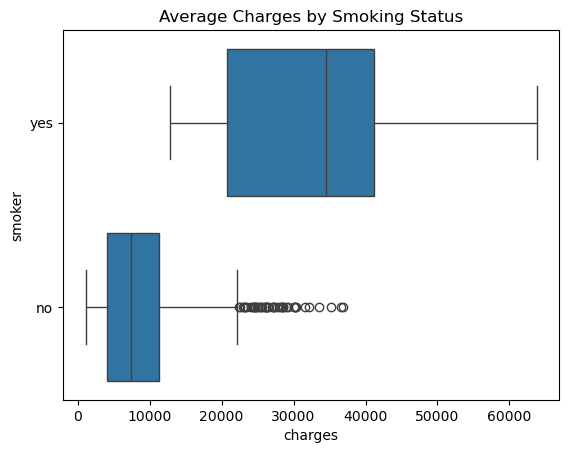

In [31]:
sns.boxplot(data=data, x="charges", y="smoker")
plt.title("Average Charges by Smoking Status")
plt.show()

Insight:

Smokers have significantly higher charges than non-smokers,
confirming smoking status as the main cost driver.

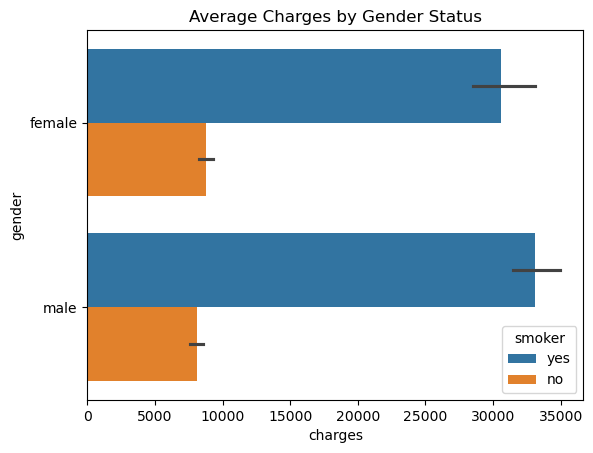

In [32]:
sns.barplot(data=data, x="charges", y="gender", hue="smoker")
plt.title("Average Charges by Gender Status")
plt.savefig("images/avg_charges_by_gender.png", dpi=300, bbox_inches='tight')
plt.show()

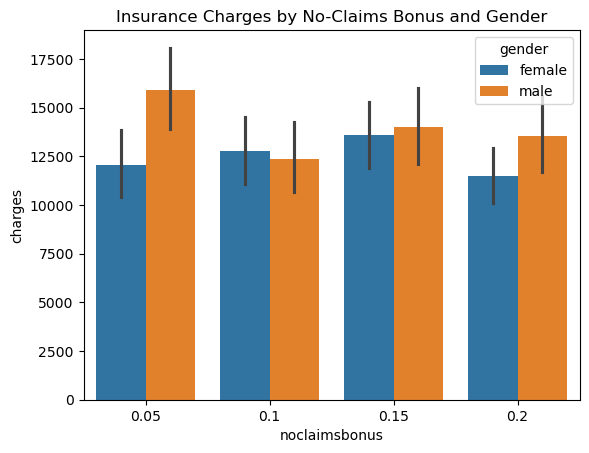

In [33]:
sns.barplot(data=data, x="noclaimsbonus", y="charges", hue="gender")
plt.title("Insurance Charges by No-Claims Bonus and Gender")
plt.show()

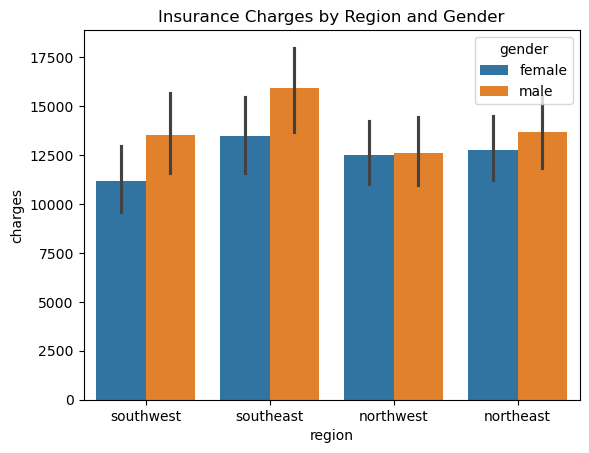

In [34]:
sns.barplot(data=data, x="region", y="charges", hue="gender")
plt.title("Insurance Charges by Region and Gender")
plt.show()

This bar plot shows the **average medical charges (charges)** for males and females. From the plot, it can be seen that the average charges for **males** are higher than those for **females**.

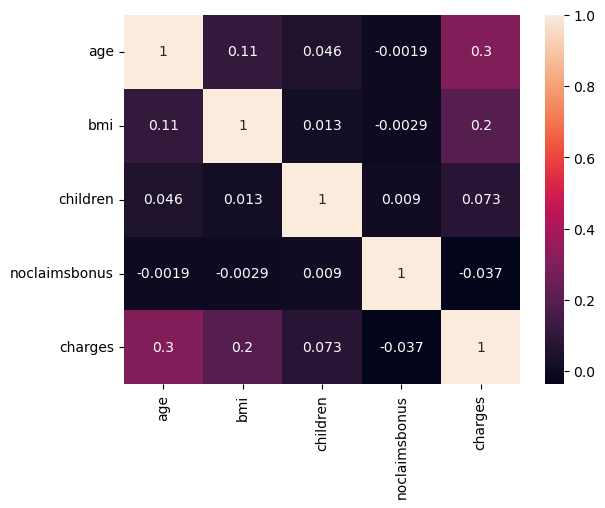

In [35]:
sns.heatmap(data.corr(numeric_only = True), annot = True)
plt.show()

The heatmap shows that smoker status has the strongest positive correlation with charges, followed by age and bmi.

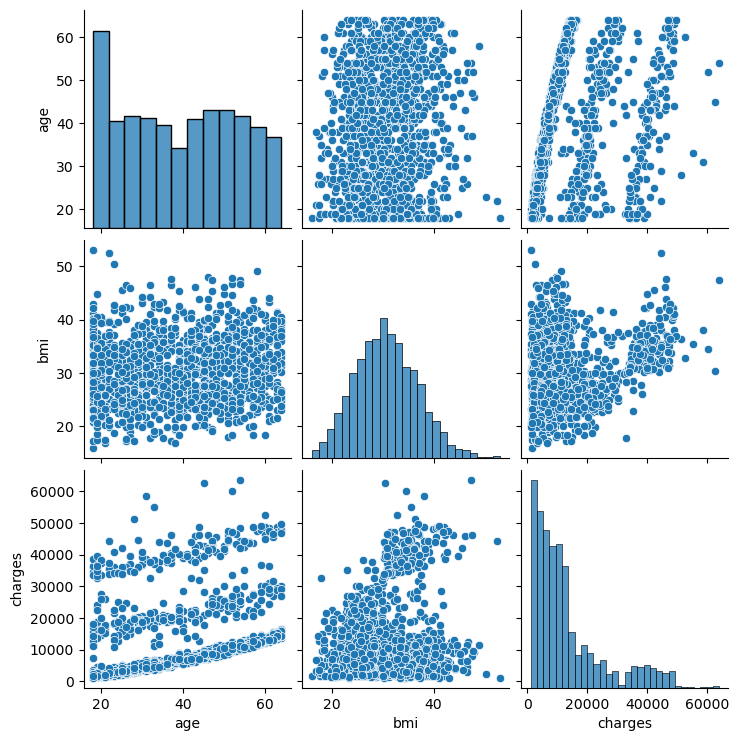

In [36]:
sns.pairplot(data = data, vars = ['age', 'bmi', 'charges'])
plt.show()

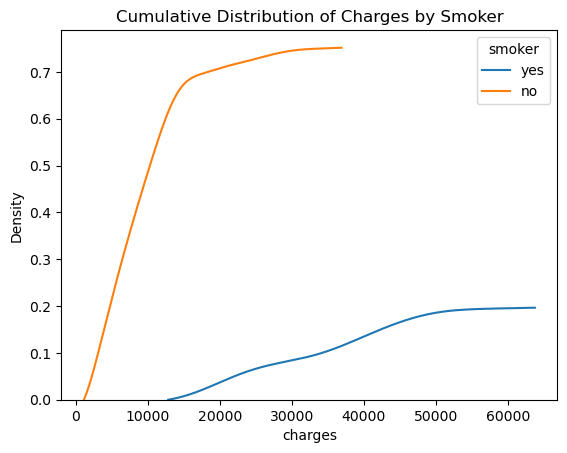

In [37]:
sns.kdeplot(data = data, x='charges', hue='smoker', cut=0, cumulative=True)
plt.title('Cumulative Distribution of Charges by Smoker')
plt.show()

The cumulative density plot reveals a sharp distinction in medical costs based on smoking status. While the majority of non-smokers incur charges below $15,000, the cost distribution for smokers typically begins around this threshold and extends significantly higher. This confirms that smoking status is a primary determinant of higher insurance charges.

In [38]:
data['smoker'].value_counts()

smoker
no     1045
yes     268
Name: count, dtype: int64

In [39]:
pd.crosstab(data["region"], data["noclaimsbonus"])

noclaimsbonus,0.05,0.10,0.15,0.20
region,,,,
northeast,81,83,72,81
northwest,72,78,72,98
southeast,101,93,86,76
southwest,76,76,94,74


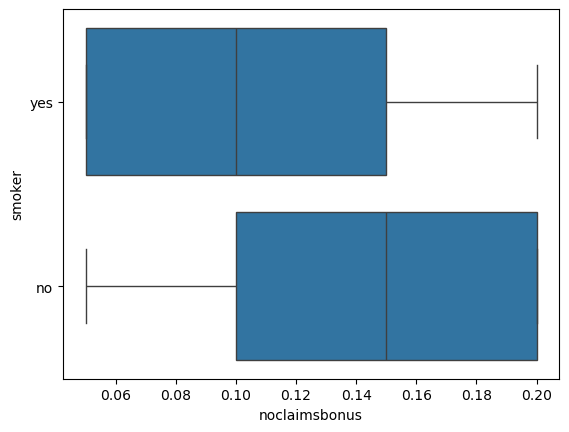

In [40]:
sns.boxplot(data=data, x="noclaimsbonus", y="smoker")
plt.show()

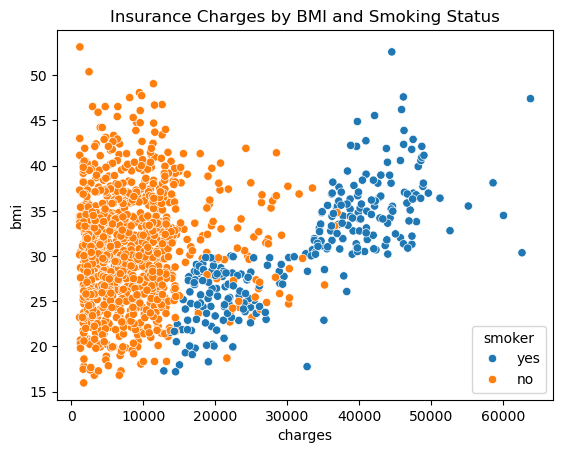

In [41]:
sns.scatterplot(data=data, x="charges", y="bmi", hue="smoker")
plt.title('Insurance Charges by BMI and Smoking Status')
plt.savefig("images/bmi_vs_charges.png", dpi=300, bbox_inches='tight')
plt.show()

The scatterplot displays the correlation between BMI and medical charges.
There is a visible cluster of data points showing a positive correlation: as BMI increases, charges tend to increase.

Interestingly, this trend is most aggressive for customers who are also smokers (often seen in the upper-right quadrant of the plot). For non-smokers, an increase in BMI does not always result in a drastic increase in charges, suggesting that obesity combined with smoking creates a compounding effect on medical costs.

## 5. Inferential Statistics: Hypothesis Testing

In this section, inferential statistical methods were applied to draw conclusions about the broader population of insurance beneficiaries based on the sample data. Two specific hypotheses were formulated to test the impact of lifestyle choices (smoking) and demographics (gender) on medical charges. An Independent Samples T-test was utilized for both analyses, with a significance level (alpha) set at 0.05 (5%).

### 5.1. Hypothesis 1: The Impact of Smoking on Medical CostsRationale: 

The Exploratory Data Analysis (EDA) visually suggested a substantial disparity in charges between smokers and non-smokers. This test aims to statistically validate whether this difference is significant.

* Null Hypothesis ($H_0$): There is no significant difference in the average medical charges between smokers and non-smokers ($\mu_{smoker} = \mu_{non-smoker}$).

* Alternative Hypothesis ($H_1$): There is a significant difference in the average medical charges between smokers and non-smokers ($\mu_{smoker} \neq \mu_{non-smoker}$).

In [42]:
from scipy import stats

# Hypothesis 1: Impact of Smoking on Price
smokers = data[data['smoker'] == 'yes']['charges']
non_smokers = data[data['smoker'] == 'no']['charges']

t_stat_smoke, p_val_smoke = stats.ttest_ind(smokers, non_smokers)
print(f"T-statistic: {t_stat_smoke:.2f}")
print(f"P-value: {p_val_smoke:}")

if p_val_smoke < 0.05:
    print("Result: Reject Null Hypothesis (Significant difference)")
else:
    print("Result: Fail to Reject Null Hypothesis")

print("\n")

T-statistic: 46.18
P-value: 3.199357261078298e-277
Result: Reject Null Hypothesis (Significant difference)




Test Results:An Independent Samples T-test was conducted comparing the charges of smokers (n= approx 270) against non-smokers (n= approx 1000).

T-statistic: 46.18
P-value: 3.199357261078298e-277
Conclusion: Since the p-value is significantly lower than the alpha level of 0.05 (p < 0.05), we reject the Null Hypothesis. There is strong statistical evidence to conclude that smoking status significantly impacts medical charges. This confirms the EDA findings and suggests that the insurance company is justified in applying a substantial premium loading for smokers to cover the increased risk.

### 5.2. Hypothesis 2: Gender Disparities in Medical Costs

Rationale: It is important for the insurance company to ensure pricing fairness and understand if gender correlates with higher medical expenses.

Null Hypothesis ($H_0$): There is no significant difference in average medical charges between male and female beneficiaries ($\mu_{male} = \mu_{female}$).

Alternative Hypothesis ($H_1$): There is a significant difference in average medical charges between male and female beneficiaries ($\mu_{male} \neq \mu_{female}$).

In [43]:
charges_female = data[data['gender'] == 'female']['charges']
charges_male = data[data['gender'] == 'male']['charges']

t_stat_g, p_value_g = stats.ttest_ind(charges_female, charges_male)

# print("\n--- Hypothesis Test 2: Gender vs Charges ---")
print(f"T-statistic: {t_stat_g:.4f}")
print(f"P-value: {p_value_g:.4f}")

if p_value_g < 0.05:
    print("Result: Reject Null Hypothesis (Significant difference)")
else:
    print("Result: Fail to Reject Null Hypothesis (No significant difference)")

T-statistic: -2.2728
P-value: 0.0232
Result: Reject Null Hypothesis (Significant difference)


Test Results:An Independent Samples T-test was performed on the charges variable grouped by sex.

T-statistic: -2.2728 P-value: 0.0232

The calculated p-value is 0.0232, which is slightly less than 0.05. Therefore, we reject the Null Hypothesis. The data suggests a statistically significant difference in charges between genders, with males incurring slightly higher costs on average. However, compared to the smoking variable, the effect size is much smaller. The insurance company should investigate whether this difference is driven by biological factors or if it is a confounder (e.g., if males in the dataset are more likely to be smokers).

### 5.3 Implications of Findings

Smoking as a Primary Cost Driver: The extremely high T-statistic (46.18) confirms that smoking is the most significant determinant of medical charges. Consequently, the insurance company must apply substantial premium loadings for smokers to cover the considerably higher risk and ensure financial sustainability.Gender-Based Pricing Caution: While there is a statistically significant difference in charges between genders (
), the effect size is small compared to smoking. The slightly higher costs for males may be influenced by other lifestyle factors. Therefore, the company should prioritize lifestyle metrics (like smoking and BMI) over gender when calculating base premiums to ensure fair pricing.

## 6. Inferential Statistics: Confidence Interval

Objective: The final statistical task addresses the question: "What is the real average price of the clients at this company at a 5% significance level?" Since we are working with a sample of the population, calculating the exact "real" average is impossible. However, we can estimate a range (interval) in which the true population mean likely resides with 95% confidence.

Methodology: To calculate the 95% Confidence Interval for the mean medical charges, the following parameters were used:

Sample Mean ( 
x
ˉ
 ): The average charge observed in our cleaned dataset.

Sample Standard Deviation (s): The measure of variability in the charges.

Sample Size (n): The number of observations (approx. 1,316).

Confidence Level: 95% (corresponding to a 5% significance level, α=0.05).

The interval was calculated using the T-distribution method (due to the unknown population standard deviation), using the formula:

In [45]:
# --- Confidence Interval ---

# Task: Calculate the real average price (charges) at a 5% significance level (95% Confidence Level).

# Calculate mean and standard error of the mean (SEM)
mean_charge = data['charges'].mean()
sem_charge = stats.sem(data['charges'])
n = len(data['charges'])

# Calculate 95% Confidence Interval using t-distribution
confidence_level = 0.95
degrees_freedom = n - 1
ci_lower, ci_upper = stats.t.interval(confidence_level, degrees_freedom, loc=mean_charge, scale=sem_charge)

print("--- 95% Confidence Interval for Average Charges ---")
print(f"Sample Mean: ${mean_charge:.2f}")
print(f"95% Confidence Interval: (${ci_lower:.2f}, ${ci_upper:.2f})")
print(f"\nInterpretation: We are 95% confident that the true population mean of medical charges lies between ${ci_lower:.2f} and ${ci_upper:.2f}.")

--- 95% Confidence Interval for Average Charges ---
Sample Mean: $13260.62
95% Confidence Interval: ($12605.05, $13916.18)

Interpretation: We are 95% confident that the true population mean of medical charges lies between $12605.05 and $13916.18.


Results: Based on the analysis, the 95% confidence interval for the mean medical charges is: 12605 to 13,916.

Interpretation & Conclusion: We can state with 95% confidence that the real average medical cost for the entire population of clients at this insurance company lies between 12605 and 13916. This interval is crucial for financial planning. It suggests that while individual claims vary significantly (as seen in the descriptive statistics), the company can expect the long-term average cost per client to fall within this specific range.

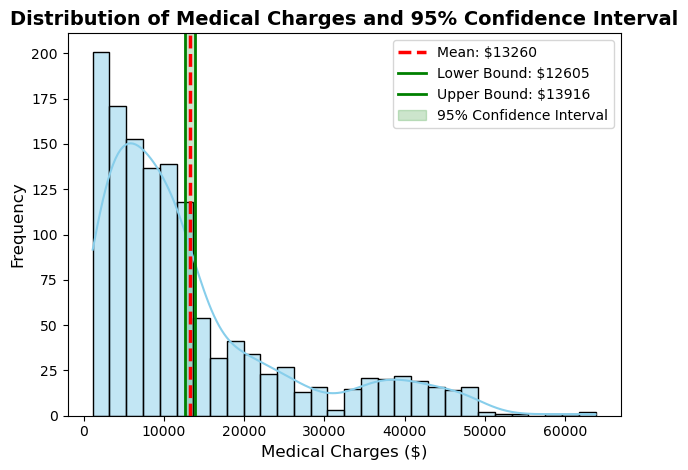

In [52]:
mean_charge = 13260
ci_lower = 12605
ci_upper = 13916

sns.histplot(data['charges'], kde=True, color='skyblue', bins=30, alpha=0.5)

plt.axvline(mean_charge, color='red', linestyle='--', linewidth=2.5, label=f'Mean: ${mean_charge}')
plt.axvline(ci_lower, color='green', linestyle='-', linewidth=2, label=f'Lower Bound: ${ci_lower}')
plt.axvline(ci_upper, color='green', linestyle='-', linewidth=2, label=f'Upper Bound: ${ci_upper}')

plt.axvspan(ci_lower, ci_upper, color='green', alpha=0.2, label='95% Confidence Interval')

plt.title('Distribution of Medical Charges and 95% Confidence Interval', fontsize=14, fontweight='bold')
plt.xlabel('Medical Charges ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("images/conf_interval.png", dpi=300, bbox_inches='tight')
plt.show()